In [143]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import torch
from torch import nn, optim
from torch.autograd import Variable
from torch.utils.data import DataLoader
import torch.utils.data as Data
from torchvision import transforms, datasets

In [144]:
# 文件读取
def get_Data(data_path):

    data=pd.read_excel(data_path)
    data=data.iloc[:,:3]  # 以三个特征作为数据
    label=data.iloc[:,2:] # 取最后一个特征作为标签
    print(data.head())
    print(label.head())
    return data,label

In [145]:
def normalization(data,label):
    """
    数据归一化
    """

    # 创建两个归一化容器实例
    mm_x=MinMaxScaler() 
    mm_y=MinMaxScaler()
    
    # DataFrame转化为numpy数组
    data=data.values    
    label=label.values

    # 计算特征数据 data 的最小值和最大值，并将数据缩放到[0,1]范围内
    data=mm_x.fit_transform(data) 

    # 计算标签数据 label 的最小值和最大值，并将数据缩放到[0,1]范围内
    label=mm_y.fit_transform(label)

    # 返回归一化后的数据和标签，mmy 是为了在后续的反归一化步骤中使用，以便将预测结果转换回原始的尺度
    return data,label,mm_y

In [146]:
def split_windows(data,seq_length):
    """将时间序列数据转换为适合用于训练 LSTM 模型的输入和输出格式"""

    # 初始化列表
    x=[]
    y=[]
    
    # 遍历数据
    for i in range(len(data)-seq_length-1): # range的范围需要减去时间步长和1
        _x=data[i:(i+seq_length),:]  # 从data中提取的长度为seq_length的子序列，用于作为模型的输入
        _y=data[i+seq_length,-1] # 从data中提取的目标值，即_x子序列之后的一个时间步的数据点的最后一个值，用于作为模型的输出

        # 将每一次循环提取的输入_x和输出_y分别添加到列表x和y中
        x.append(_x)
        y.append(_y)

    # 将列表x和y转换为NumPy数组
    x,y=np.array(x),np.array(y)

    # 打印形状
    print('x.shape,y.shape=\n',x.shape,y.shape)
    return x,y

In [147]:
def split_data(x,y,split_ratio):
    """
    将输入的数据集分为训练集和测试集
    :param x: 数据集特征
    :param y: 数据集目标变量
    :param split_ratio: 训练集占比
    :return: 转换后的数据集特征和目标变量，训练集特征和目标变量，测试集特征和目标变量
    """

    # 训练集的大小
    train_size=int(len(y)*split_ratio)
    
    # 将x和y转换为torch.Tensor对象：使用np.array()将它们转换为NumPy数组，然后用torch.Tensor()将NumPy数组转换为PyTorch的张量。Variable是PyTorch中用于包装张量的类，使其可以被自动微分系统跟踪
    x_data=Variable(torch.Tensor(np.array(x)))
    y_data=Variable(torch.Tensor(np.array(y)))

    # 分离训练集和测试集
    x_train=Variable(torch.Tensor(np.array(x[0:train_size])))
    y_train=Variable(torch.Tensor(np.array(y[0:train_size])))
    y_test=Variable(torch.Tensor(np.array(y[train_size:len(y)])))
    x_test=Variable(torch.Tensor(np.array(x[train_size:len(x)])))

    # 打印出各数据集的形状
    print('x_data.shape,y_data.shape,x_train.shape,y_train.shape,x_test.shape,y_test.shape:\n{}{}{}{}{}{}'
    .format(x_data.shape,y_data.shape,x_train.shape,y_train.shape,x_test.shape,y_test.shape))

    # 返回分离后的数据集
    return x_data,y_data,x_train,y_train,x_test,y_test

In [148]:
def data_generator(x_train,y_train,x_test,y_test,n_iters,batch_size):
    """
    生成训练和测试数据加载器，并计算在给定迭代次数下的训练轮数（epochs）
    :param x_train: 训练集特征
    :param y_train: 训练集标签
    :param x_test: 测试集特征
    :param y_test: 测试集标签
    :param n_iters: 迭代次数
    :param batch_size: 每次迭代使用的数量批次大小
    :return: 训练集加载器，测试集加载器，训练轮数
    """

    # 计算训练轮数
    num_epochs=n_iters/(len(x_train)/batch_size) # 计算训练轮数
    num_epochs=int(num_epochs) # 取整

    # 创建训练和测试数据集
    # 将输入的特征和标签数据组合成PyTorch的数据集对象
    train_dataset=Data.TensorDataset(x_train,y_train) 
    test_dataset=Data.TensorDataset(x_test,y_test)

    # 创建训练和测试数据加载器
    # shuffle=False 表示在每个epoch开始时，不打乱数据的顺序
    # drop_last=True 表示如果最后一个batch的大小小于batch_size，则丢弃最后一个batch
    train_loader=torch.utils.data.DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=False,drop_last=True) # 加载数据集,使数据集可迭代
    test_loader=torch.utils.data.DataLoader(dataset=test_dataset,batch_size=batch_size,shuffle=False,drop_last=True)

    # 返回数据加载器和训练轮数
    return train_loader,test_loader,num_epochs

In [149]:
# 定义模型
from turtle import forward
import torch.nn as nn
import torch.nn.functional as F

# 定义一个类
class Net(nn.Module):
    def __init__(self,input_size,hidden_size,num_layers,output_size,batch_size,seq_length) -> None:
        super(Net,self).__init__()
        # 输入特征维度
        self.input_size=input_size
        # 隐藏层特征维度
        self.hidden_size=hidden_size
        # LSTM层数
        self.num_layers=num_layers
        # 输出特征维度
        self.output_size=output_size
        # 批次大小
        self.batch_size=batch_size
        # 序列长度
        self.seq_length=seq_length
        self.num_directions=1 # 单向LSTM
        # LSTM层
        self.lstm=nn.LSTM(input_size=input_size,hidden_size=hidden_size,num_layers=num_layers,batch_first=True)
        # 全连接层
        self.fc=nn.Linear(hidden_size,output_size)
    
    # 前向传播
    def forward(self,x):
        # 从输入张量 x 中提取批次大小和序列长度
        batch_size, seq_len = x.size()[0], x.size()[1]    # x.shape=(604,3,3)

        # 初始化LSTM的隐藏状态
        h_0 = torch.randn(self.num_directions * self.num_layers, x.size(0), self.hidden_size)

        # 初始化LSTM的细胞状态
        c_0 = torch.randn(self.num_directions * self.num_layers, x.size(0), self.hidden_size)
        
        # 输入 x 和隐藏状态 h_0, c_0 到 LSTM 层
        # output(seq_len, batch, hidden_size)
        output, _ = self.lstm(x, (h_0, c_0)) # output(5, 30, 64)

        # 将 LSTM 的输出传递给全连接层，得到预测结果 pred
        pred = self.fc(output)  # (5, 30, 1)

        # 取最后一个时间步的输出作为预测结果
        pred = pred[:, -1, :]  # (5, 1)
        return pred

In [150]:
# 参数设置
seq_length=3 # 输入序列的时间步长，即模型在做预测时会用过去3个时间点的数据
input_size=3 # 输入序列的特征维度
num_layers=6 # LSTM的层数
hidden_size=12 # LSTM层的隐藏单元数
batch_size=64  # 每次输入网络的数量批次大小
n_iters=5000 # 训练的迭代次数
lr=0.001 # 优化器的学习率
output_size=1 # 输出的维度
split_ratio=0.9 # 训练集和测试集的划分比例
path='zhangwenhao/data.xls'
moudle=Net(input_size,hidden_size,num_layers,output_size,batch_size,seq_length)
criterion=torch.nn.MSELoss() #定义损失函数为均方误差损失
optimizer=torch.optim.Adam(moudle.parameters(),lr=lr) # 定义优化器为Adam优化器
print(moudle)

Net(
  (lstm): LSTM(3, 12, num_layers=6, batch_first=True)
  (fc): Linear(in_features=12, out_features=1, bias=True)
)


In [151]:
# 数据导入
data,label=get_Data(path)
# 数据归一化
data,label,mm_y=normalization(data,label)
# 数据切分
x,y=split_windows(data,seq_length)
# 数据集制作
x_data,y_data,x_train,y_train,x_test,y_test=split_data(x,y,split_ratio)
# 数据加载器生成
train_loader,test_loader,num_epochs=data_generator(x_train,y_train,x_test,y_test,n_iters,batch_size)

   导叶开度  燃料流量m3N/h  压气机出口温度
0     1     0.0089      1.0
1     2     0.0179      2.0
2     3     0.0269      2.0
3     6     0.0359      3.0
4     8     0.0449      4.0
   压气机出口温度
0      1.0
1      2.0
2      2.0
3      3.0
4      4.0
x.shape,y.shape=
 (604, 3, 3) (604,)
x_data.shape,y_data.shape,x_train.shape,y_train.shape,x_test.shape,y_test.shape:
torch.Size([604, 3, 3])torch.Size([604])torch.Size([543, 3, 3])torch.Size([543])torch.Size([61, 3, 3])torch.Size([61])


In [152]:
# train
iter=0  # 记录迭代次数
for epochs in range(num_epochs):
  for i,(batch_x, batch_y) in enumerate (train_loader):
    outputs = moudle(batch_x) 
    optimizer.zero_grad()   # 将每次传播时的梯度累积清除
    loss = criterion(outputs,batch_y) # 计算损失
    loss.backward() # 反向传播
    optimizer.step() # 更新参数
    iter+=1
    if iter % 100 == 0:
      print("iter: %d, loss: %1.5f" % (iter, loss.item()))

/root/miniconda3/envs/zhanjiang/lib/python3.10/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


iter: 100, loss: 0.02455
iter: 200, loss: 0.10417
iter: 300, loss: 0.02358
iter: 400, loss: 0.09963
iter: 500, loss: 0.02446
iter: 600, loss: 0.00757
iter: 700, loss: 0.00060
iter: 800, loss: 0.00422
iter: 900, loss: 0.00099
iter: 1000, loss: 0.00342
iter: 1100, loss: 0.00057
iter: 1200, loss: 0.00360
iter: 1300, loss: 0.00040
iter: 1400, loss: 0.00352
iter: 1500, loss: 0.00084
iter: 1600, loss: 0.00329
iter: 1700, loss: 0.00067
iter: 1800, loss: 0.00350
iter: 1900, loss: 0.00079
iter: 2000, loss: 0.00316
iter: 2100, loss: 0.00069
iter: 2200, loss: 0.00351
iter: 2300, loss: 0.00089
iter: 2400, loss: 0.00336
iter: 2500, loss: 0.00056
iter: 2600, loss: 0.00379
iter: 2700, loss: 0.00062
iter: 2800, loss: 0.00308
iter: 2900, loss: 0.00039
iter: 3000, loss: 0.00375
iter: 3100, loss: 0.00058
iter: 3200, loss: 0.00335
iter: 3300, loss: 0.00062
iter: 3400, loss: 0.00303
iter: 3500, loss: 0.00050
iter: 3600, loss: 0.00335
iter: 3700, loss: 0.00081
iter: 3800, loss: 0.00317
iter: 3900, loss: 0.0

In [153]:
print(x_data.shape)

torch.Size([604, 3, 3])


In [154]:
# 将模型设置为评估模式
moudle.eval()

# 使用模型对输入数据进行预测
train_predict = moudle(x_data)

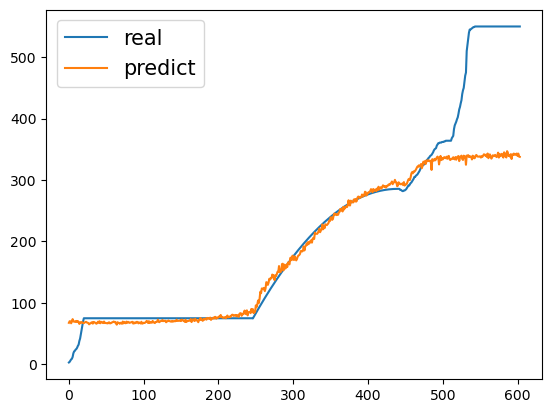

MAE/RMSE
34.76924133300781
74.72718937596443


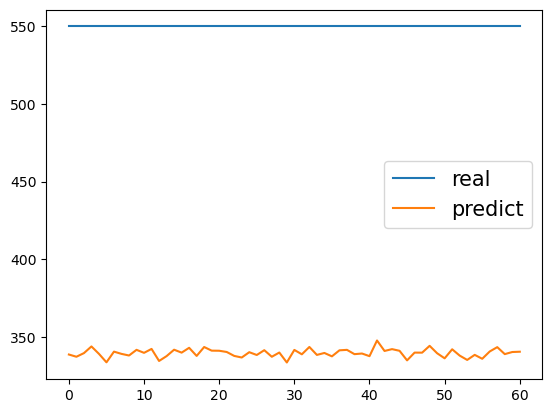

MAE/RMSE
210.522705078125
210.53963403596958


In [155]:
def result(x_data, y_data):
  """
  评估和展示一个基于PyTorch的模型（在这里被称为moudle）对给定数据的预测性能
  Args:
    x_data: 输入数据
    y_data: 真实值
  Returns:
    无返回值，展示预测值和真实值的对比图以及评估指标
  """

  # 将模型设置为评估模式
  moudle.eval()

  # 预测值
  train_predict = moudle(x_data)

  # 将预测结果转换为NumPy数组，以便后续处理
  data_predict = train_predict.data.numpy()
  y_data_plot = y_data.data.numpy()

  #  重塑真实输出数据的形状，使其与预测数据的形状一致，便于后续的逆归一化处理
  y_data_plot = np.reshape(y_data_plot, (-1,1))  

  # 逆归一化处理
  data_predict = mm_y.inverse_transform(data_predict)
  y_data_plot = mm_y.inverse_transform(y_data_plot)

  # 绘制预测结果与真实结果
  plt.plot(y_data_plot)
  plt.plot(data_predict)
  plt.legend(('real', 'predict'),fontsize='15')
  plt.show()

  # 计算误差指标
  print('MAE/RMSE')
  print(mean_absolute_error(y_data_plot, data_predict))
  print(np.sqrt(mean_squared_error(y_data_plot, data_predict) ))

result(x_data, y_data)
result(x_test,y_test)